In [7]:
# Always start at base directory for imports
%cd
%cd dev2/scaling-laws-ecnn/
%load_ext autoreload
%autoreload 2
import pandas as pd
pd.set_option('display.max_columns', None)
import torch
from typing import List


import sys
import os
from plotting.experiments.b_NAS.plot_nas_results import scalar_mappable
from experiments.b_NAS.common_best_architecture.util import *
from experiments.b_NAS.util import *
from experiments.run_command import run_command
from experiments.d_application.utils_HPO import HPOEarlyStopper



/home/frischs
/home/frischs/dev2/scaling-laws-ecnn
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def test():
    # test plateau stopper

    valid_accs =[0.762499988079071, 0.759999990463257, 0.730000019073486, 0.75, 0.774999976158142, 0.75, 0.774999976158142, 0.740000009536743, 0.725000023841858, 0.759999990463257, 0.774999976158142, 0.774999976158142, 0.774999976158142, 0.774999976158142, 0.762499988079071, 0.774999976158142, 0.774999976158142, 0.774999976158142, 0.774999976158142, 0.764999985694885, 0.759999990463257, 0.774999976158142, 0.759999990463257, 0.774999976158142, 0.774999976158142, 0.767499983310699, 0.774999976158142, 0.75, 0.757499992847443, 0.757499992847443, 0.759999990463257, 0.752499997615814, 0.752499997615814, 0.747500002384186, 0.754999995231628, 0.757499992847443, 0.737500011920929, 0.754999995231628, 0.762499988079071, 0.759999990463257, 0.732500016689301, 0.769999980926514, 0.685000002384186, 0.707499980926514, 0.742500007152557, 0.670000016689301, 0.702499985694885, 0.742500007152557, 0.675000011920929, 0.714999973773956, 0.725000023841858, 0.567499995231628]
    # reverse order the list
    valid_accs = valid_accs[::-1]
    indices = list(range(len(valid_accs)))

    print(valid_accs)

    stopper = ExperimentPlateauStopper(
        metric="valid_acc", 
        std=0.001, 
        top=10, 
        mode="max", 
        patience=3, 
        min_trials=5
    )

    for i, acc in enumerate(valid_accs):
        print(f"Epoch {i} - acc: {acc}")
        stop = stopper(None, {"valid_acc": acc})
        print(f"Stop: {stop}")
        if stop:
            break


ModuleNotFoundError: No module named 'plot'

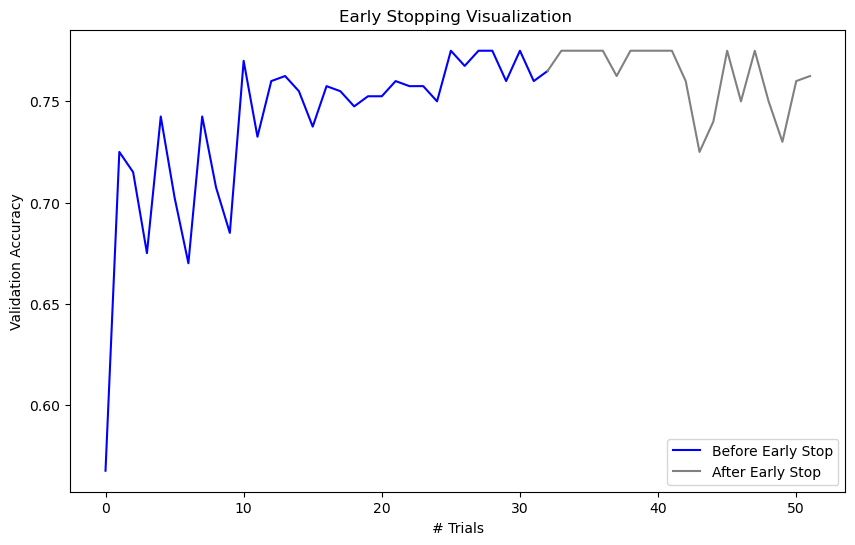

In [10]:
import matplotlib.pyplot as plt
#from your_early_stopper_import import ExperimentPlateauStopper  # Replace with the actual import

def test(valid_accs):
    valid_accs = valid_accs[::-1]
    indices = list(range(len(valid_accs)))

    stopper = HPOEarlyStopper(
        metric="valid_acc", 
        mode="max", 
        patience=7, 
        min_delta=0.001,
        min_num_trials=25
    )

    stop_index = None
    for i, acc in enumerate(valid_accs):
        stop = stopper(None, {"valid_acc": acc})
        if stop:
            stop_index = i
            break

    # Plotting
    plt.figure(figsize=(10, 6))
    
    if stop_index is not None:
        plt.plot(indices[:stop_index+1], valid_accs[:stop_index+1], 'b', label='Before Early Stop')
        plt.plot(indices[stop_index:], valid_accs[stop_index:], 'gray', label='After Early Stop')
    else:
        plt.plot(indices, valid_accs, 'b', label='No Early Stop')
    
    plt.xlabel('# Trials')
    plt.ylabel('Validation Accuracy')
    plt.title('Early Stopping Visualization ')
    plt.legend()
    plt.show()



valid_accs =[0.762499988079071, 0.759999990463257, 0.730000019073486, 0.75, 0.774999976158142, 0.75, 0.774999976158142, 0.740000009536743, 0.725000023841858, 0.759999990463257, 0.774999976158142, 0.774999976158142, 0.774999976158142, 0.774999976158142, 0.762499988079071, 0.774999976158142, 0.774999976158142, 0.774999976158142, 0.774999976158142, 0.764999985694885, 0.759999990463257, 0.774999976158142, 0.759999990463257, 0.774999976158142, 0.774999976158142, 0.767499983310699, 0.774999976158142, 0.75, 0.757499992847443, 0.757499992847443, 0.759999990463257, 0.752499997615814, 0.752499997615814, 0.747500002384186, 0.754999995231628, 0.757499992847443, 0.737500011920929, 0.754999995231628, 0.762499988079071, 0.759999990463257, 0.732500016689301, 0.769999980926514, 0.685000002384186, 0.707499980926514, 0.742500007152557, 0.670000016689301, 0.702499985694885, 0.742500007152557, 0.675000011920929, 0.714999973773956, 0.725000023841858, 0.567499995231628]

test(valid_accs)